<a href="https://colab.research.google.com/github/Nasaty/Portfolio-Data-Science/blob/main/Copia_de_TelecomX_Analisis_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- LIBRERÍAS PARA EL ANÁLISIS DE TELECOM X ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import datetime
import chardet
from scipy.stats import pointbiserialr

# Configuración para que los gráficos se vean
%matplotlib inline
sns.set_theme(style="whitegrid")

##Extraccion de datos

In [2]:
import pandas as pd
import requests

# 1. Definir la URL del archivo Raw de GitHub
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    # 2. Realizar la petición a la API/Repositorio
    response = requests.get(url)
    response.raise_for_status()  # Verifica si la descarga fue exitosa

    # 3. Cargar los datos JSON
    data = response.json()

    # 4. Convertir a DataFrame de Pandas
    df_telecom = pd.DataFrame(data)

    print(" ¡Datos cargados con éxito!")
    print(f"Dimensiones del dataset: {df_telecom.shape}")

except requests.exceptions.RequestException as e:
    print(f" Error al conectar con la API: {e}")

# Mostrar las primeras filas para inspeccionar la estructura
df_telecom.head()

 ¡Datos cargados con éxito!
Dimensiones del dataset: (7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##Exploracion tecnica

In [3]:
# Ver resumen de columnas, tipos de datos y valores nulos
df_telecom.info()

# Ver las primeras 5 filas para entender el contenido
df_telecom.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
# 1. Convertir las columnas con diccionarios en DataFrames independientes
df_customer = pd.json_normalize(df_telecom['customer'])
df_phone = pd.json_normalize(df_telecom['phone'])
df_internet = pd.json_normalize(df_telecom['internet'])
df_account = pd.json_normalize(df_telecom['account'])

# 2. Unir todo en un solo DataFrame limpio, manteniendo el customerID y Churn original
df_final = pd.concat([
    df_telecom[['customerID', 'Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

# 3. Ver el resultado de la transformación
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
# 1. Convertir Charges.Total a numérico.
# 'errors=coerce' transformará los espacios en blanco en valores NaN (nulos)
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# 2. Verificar cuántos valores nulos aparecieron después de la conversión
print(f"Valores nulos en Charges.Total: {df_final['Charges.Total'].isnull().sum()}")

# 3. Llenar esos nulos con 0 (ya que son clientes que probablemente no han completado un mes)
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

# 4. Verificamos los tipos de datos finales
print(df_final[['Charges.Monthly', 'Charges.Total']].dtypes)

Valores nulos en Charges.Total: 11
Charges.Monthly    float64
Charges.Total      float64
dtype: object


In [ ]:
# Ver la distribución del Churn
print(df_final['Churn'].value_counts(normalize=True) * 100)

Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


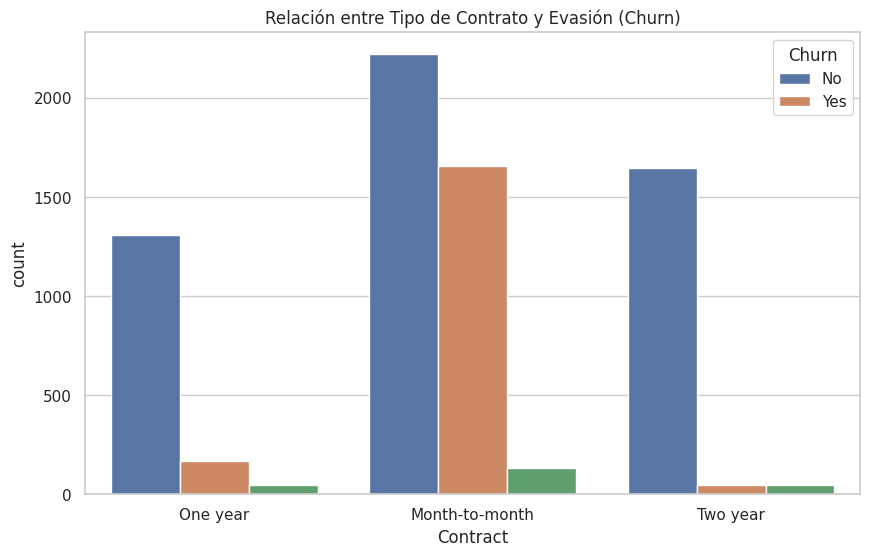

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='Contract', hue='Churn')
plt.title('Relación entre Tipo de Contrato y Evasión (Churn)')
plt.show()

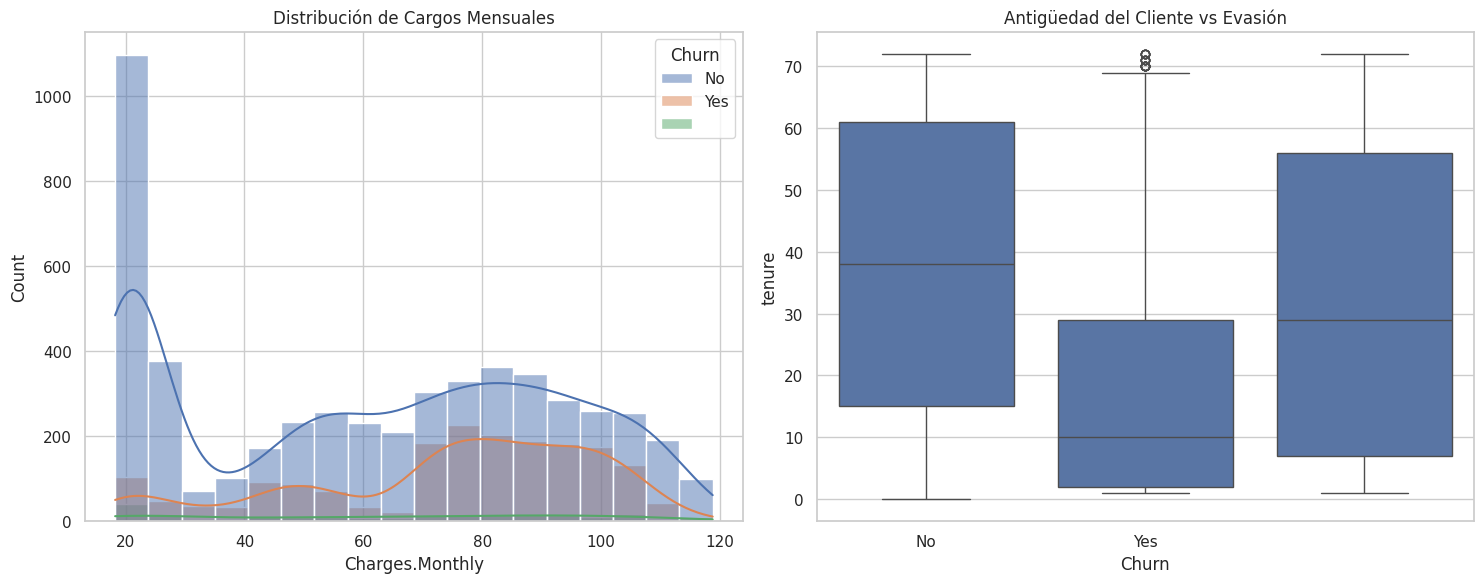

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear una figura con dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histograma de Cargos Mensuales según Churn
sns.histplot(data=df_final, x='Charges.Monthly', hue='Churn', kde=True, ax=axes[0])
axes[0].set_title('Distribución de Cargos Mensuales')

# 2. Boxplot de Antigüedad (Tenure) según Churn
sns.boxplot(data=df_final, x='Churn', y='tenure', ax=axes[1])
axes[1].set_title('Antigüedad del Cliente vs Evasión')

plt.tight_layout()
plt.show()

##Comprobación de incoherencias en los datos

In [ ]:
# Convertir a numérico y detectar nulos
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# Ver cuántos nulos hay en todo el dataset
print("Valores nulos por columna:")
print(df_final.isnull().sum())

Valores nulos por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [ ]:
# Verificar cuántas filas duplicadas existen
print(f"Filas duplicadas: {df_final.duplicated().sum()}")

# Eliminar duplicados si los hay
df_final = df_final.drop_duplicates()

Filas duplicadas: 0


In [ ]:
# Revisar valores únicos en columnas clave
columnas_clave = ['Churn', 'Contract', 'InternetService', 'PaymentMethod']

for col in columnas_clave:
    print(f"Valores únicos en {col}: {df_final[col].unique()}")

Valores únicos en Churn: ['No' 'Yes' '']
Valores únicos en Contract: ['One year' 'Month-to-month' 'Two year']
Valores únicos en InternetService: ['DSL' 'Fiber optic' 'No']
Valores únicos en PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [ ]:
# Rellenar nulos en Charges.Total con 0
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

# Verificar que ya no queden nulos
print(f"Nulos restantes en Charges.Total: {df_final['Charges.Total'].isnull().sum()}")

Nulos restantes en Charges.Total: 0


##Manejo de inconsistencias

In [ ]:
# 1. Eliminar duplicados
df_final = df_final.drop_duplicates()

# 2. Corregir tipos de datos y manejar nulos en 'Charges.Total'
# Convertimos a número y los errores se vuelven NaN
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')
# Llenamos esos NaN con 0 (clientes con 0 meses de antigüedad)
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

# 3. Estandarización de Texto (Limpieza de strings)
# Vamos a convertir las columnas de texto a minúsculas y quitar espacios extra
# Esto evita que ' DSL' y 'dsl' se cuenten como diferentes
columnas_texto = df_final.select_dtypes(include=['object']).columns

for col in columnas_texto:
    # Quitamos espacios al inicio/final y pasamos a minúsculas
    df_final[col] = df_final[col].str.strip().str.lower()

# 4. Mapeo de valores inconsistentes (Opcional pero recomendado)
# Si en Churn tienes 'si'/'no' o 'yes'/'no', lo unificamos
mapeo_churn = {'yes': 'Yes', 'no': 'No'}
df_final['Churn'] = df_final['Churn'].map(mapeo_churn).fillna(df_final['Churn'])

print("✅ ¡Correcciones aplicadas con éxito!")
print(f"Total de registros finales: {len(df_final)}")

✅ ¡Correcciones aplicadas con éxito!
Total de registros finales: 7267


In [ ]:
# Comprobar si quedan nulos
print(df_final.isnull().sum().sum())

# Ver los nombres de las columnas finales para asegurar consistencia
print(df_final.columns)

0
Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')


##Columna de cuentas diarias

In [ ]:
# 1. Crear la columna Cuentas_Diarias dividiendo el cargo mensual entre 30
df_final['Cuentas_Diarias'] = df_final['Charges.Monthly'] / 30

# 2. Redondear a 2 decimales para mayor claridad
df_final['Cuentas_Diarias'] = df_final['Cuentas_Diarias'].round(2)

# 3. Visualizar las primeras filas para verificar el cálculo
print(df_final[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head())

# 4. Ver estadísticas rápidas de esta nueva métrica
print("\nResumen estadístico de Cuentas_Diarias:")
print(df_final['Cuentas_Diarias'].describe())

   customerID  Charges.Monthly  Cuentas_Diarias
0  0002-orfbo             65.6             2.19
1  0003-mknfe             59.9             2.00
2  0004-tlhlj             73.9             2.46
3  0011-igkff             98.0             3.27
4  0013-exchz             83.9             2.80

Resumen estadístico de Cuentas_Diarias:
count    7267.000000
mean        2.157292
std         1.004407
min         0.610000
25%         1.180000
50%         2.340000
75%         2.995000
max         3.960000
Name: Cuentas_Diarias, dtype: float64


##Estandarización y transformación de datos

In [ ]:
# 1. Diccionario de traducción de columnas principales
traduccion_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'tenure': 'Meses_Antiguedad',
    'Contract': 'Tipo_Contrato',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales'
}

# Renombrar columnas
df_final = df_final.rename(columns=traduccion_columnas)

# 2. Transformar la variable objetivo (Evasion) a binaria
# 'yes' -> 1, 'no' -> 0
df_final['Evasion_Binaria'] = df_final['Evasion'].map({'yes': 1, 'no': 0})

# 3. Estandarizar valores de texto (Ejemplo: traducir tipos de contrato)
mapeo_contratos = {
    'month-to-month': 'Mensual',
    'one year': 'Anual',
    'two year': 'Bianual'
}
df_final['Tipo_Contrato'] = df_final['Tipo_Contrato'].replace(mapeo_contratos)

print("✅ Estandarización y traducción completadas.")
df_final[['ID_Cliente', 'Evasion', 'Evasion_Binaria', 'Tipo_Contrato']].head()

✅ Estandarización y traducción completadas.


,ID_Cliente,Evasion,Evasion_Binaria,Tipo_Contrato
0,0002-orfbo,No,NaN,Anual
1,0003-mknfe,No,NaN,Mensual
2,0004-tlhlj,Yes,NaN,Mensual
3,0011-igkff,Yes,NaN,Mensual
4,0013-exchz,Yes,NaN,Mensual


##Análisis Descriptivo

In [ ]:
# 1. Análisis descriptivo de las variables numéricas
analisis_numerico = df_final[['Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].describe().T

# Añadimos la mediana (50%) explícitamente si queremos compararla con la media
analisis_numerico['mediana'] = df_final[['Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']].median()

print("--- Análisis Descriptivo de Telecom X ---")
print(analisis_numerico)

--- Análisis Descriptivo de Telecom X ---
                   count         mean          std    min      25%      50%  \
Meses_Antiguedad  7267.0    32.346498    24.571773   0.00    9.000    29.00   
Cargos_Mensuales  7267.0    64.720098    30.129572  18.25   35.425    70.30   
Cargos_Totales    7267.0  2277.182035  2268.648587   0.00  396.200  1389.20   
Cuentas_Diarias   7267.0     2.157292     1.004407   0.61    1.180     2.34   

                       75%      max  mediana  
Meses_Antiguedad    55.000    72.00    29.00  
Cargos_Mensuales    89.875   118.75    70.30  
Cargos_Totales    3778.525  8684.80  1389.20  
Cuentas_Diarias      2.995     3.96     2.34  


In [ ]:
# Ver el comportamiento de las variables de texto (Contrato, Internet, etc.)
print("\n--- Resumen de Variables Categóricas ---")
print(df_final.describe(include=['object']).T)


--- Resumen de Variables Categóricas ---
                 count unique               top  freq
ID_Cliente        7267   7267        9995-hotoh     1
Evasion           7267      3                No  5174
Genero            7267      2              male  3675
Partner           7267      2                no  3749
Dependents        7267      2                no  5086
PhoneService      7267      2               yes  6560
MultipleLines     7267      3                no  3495
InternetService   7267      3       fiber optic  3198
OnlineSecurity    7267      3                no  3608
OnlineBackup      7267      3                no  3182
DeviceProtection  7267      3                no  3195
TechSupport       7267      3                no  3582
StreamingTV       7267      3                no  2896
StreamingMovies   7267      3                no  2870
Tipo_Contrato     7267      3           Mensual  4005
PaperlessBilling  7267      2               yes  4311
PaymentMethod     7267      4  electroni

##Distribución de evasión

/tmp/ipykernel_202/1502622051.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='Evasion', palette='viridis', ax=ax[0])


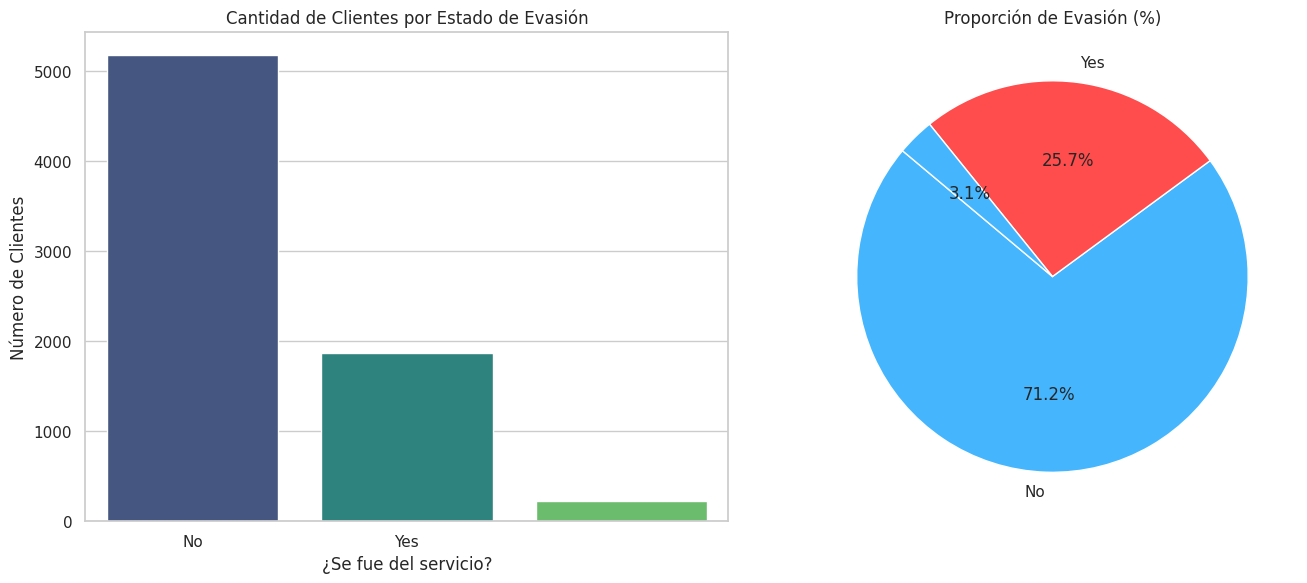

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el lienzo para dos gráficos
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de Barras (Frecuencia Absoluta)
sns.countplot(data=df_final, x='Evasion', palette='viridis', ax=ax[0])
ax[0].set_title('Cantidad de Clientes por Estado de Evasión')
ax[0].set_xlabel('¿Se fue del servicio?')
ax[0].set_ylabel('Número de Clientes')

# 2. Gráfico de Pastel (Frecuencia Relativa/Proporción)
datos_pie = df_final['Evasion'].value_counts()
ax[1].pie(datos_pie, labels=datos_pie.index, autopct='%1.1f%%', startangle=140, colors=['#45b6fe', '#ff4d4d'])
ax[1].set_title('Proporción de Evasión (%)')

plt.tight_layout()
plt.show()

##Recuento de evasión por variables categóricas

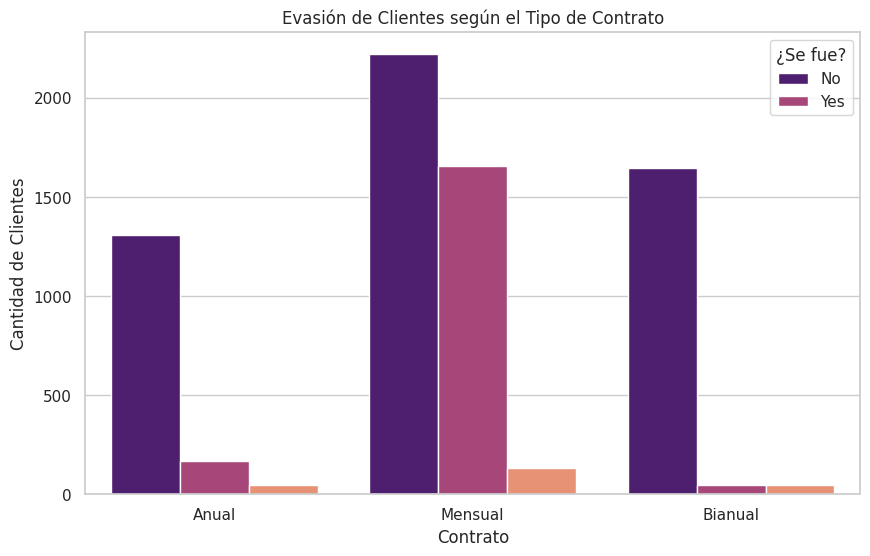

In [ ]:
# Crear un gráfico de barras agrupado por Contrato
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='Tipo_Contrato', hue='Evasion', palette='magma')
plt.title('Evasión de Clientes según el Tipo de Contrato')
plt.xlabel('Contrato')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='¿Se fue?')
plt.show()

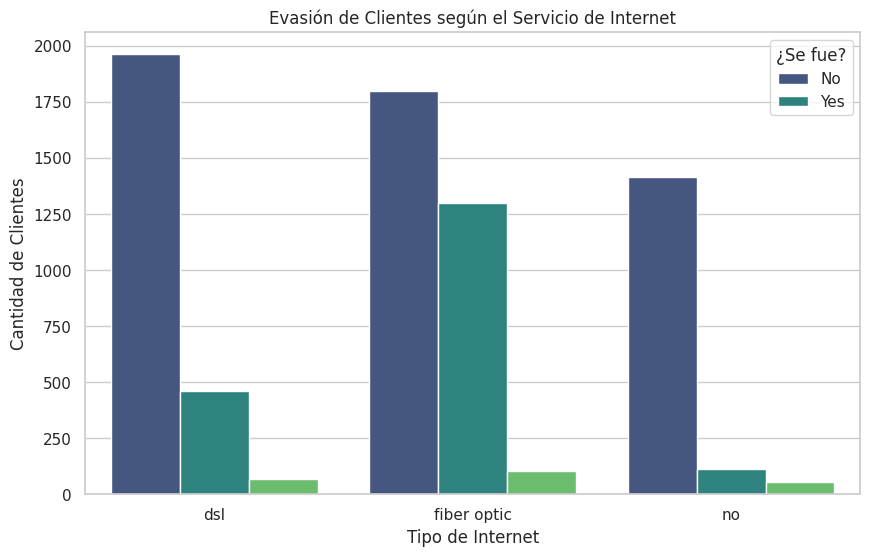

In [ ]:
# Crear un gráfico de barras agrupado por Servicio de Internet
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='InternetService', hue='Evasion', palette='viridis')
plt.title('Evasión de Clientes según el Servicio de Internet')
plt.xlabel('Tipo de Internet')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='¿Se fue?')
plt.show()

##Conteo de evasión por variables numéricas

/tmp/ipykernel_202/934884105.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasion', y='Meses_Antiguedad', palette='Set2', ax=axes[0])
/tmp/ipykernel_202/934884105.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasion', y='Cargos_Mensuales', palette='Set1', ax=axes[1])
/tmp/ipykernel_202/934884105.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasion', y='Cargos_Totales', palette='Pastel1', ax=axes[2])


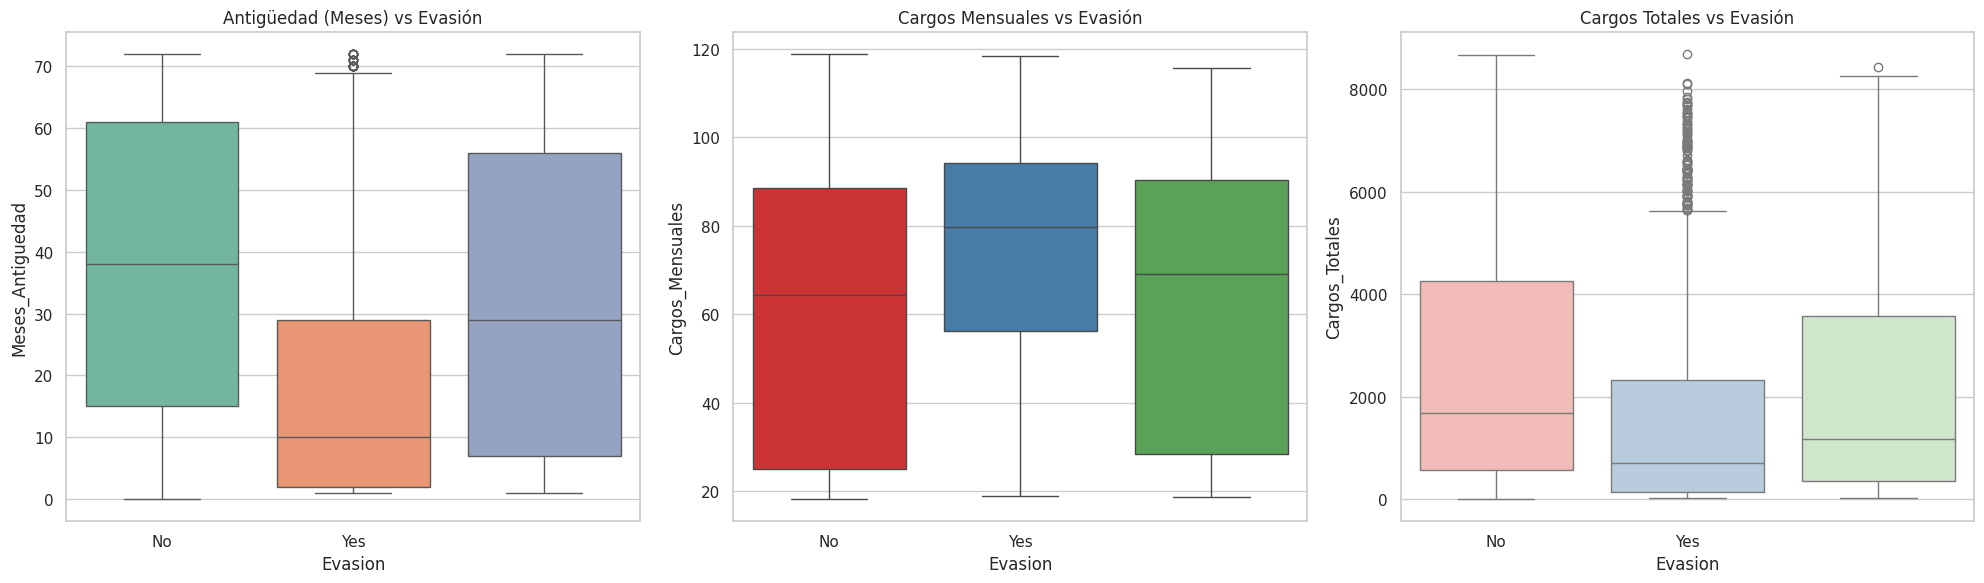

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el área de dibujo para 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Distribución de Meses de Antigüedad vs Evasión
sns.boxplot(data=df_final, x='Evasion', y='Meses_Antiguedad', palette='Set2', ax=axes[0])
axes[0].set_title('Antigüedad (Meses) vs Evasión')

# 2. Distribución de Cargos Mensuales vs Evasión
sns.boxplot(data=df_final, x='Evasion', y='Cargos_Mensuales', palette='Set1', ax=axes[1])
axes[1].set_title('Cargos Mensuales vs Evasión')

# 3. Distribución de Cargos Totales vs Evasión
sns.boxplot(data=df_final, x='Evasion', y='Cargos_Totales', palette='Pastel1', ax=axes[2])
axes[2].set_title('Cargos Totales vs Evasión')

plt.tight_layout()
plt.show()

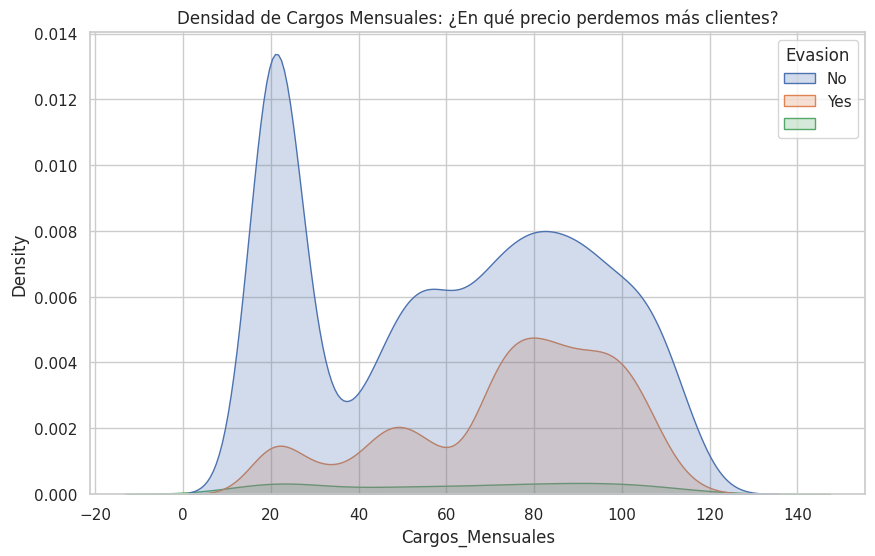

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_final, x='Cargos_Mensuales', hue='Evasion', fill=True)
plt.title('Densidad de Cargos Mensuales: ¿En qué precio perdemos más clientes?')
plt.show()

##Informe final

##Análisis de Evasión de Clientes (Churn) - Telecom X

 Introducción
El objetivo de este proyecto fue analizar el comportamiento de los clientes de Telecom X para identificar los factores que impulsan la evasión (Churn). Perder un cliente existente es mucho más costoso que adquirir uno nuevo, por lo que entender por qué se van es vital para la sostenibilidad financiera de la empresa.

Limpieza y Tratamiento de Datos (ETL)
Para asegurar la calidad del análisis, se realizaron los siguientes pasos:

Extracción y Aplanado: Los datos se extrajeron de una API donde la información estaba anidada en diccionarios. Se normalizaron para obtener un dataset de 21 columnas.

Corrección de Tipos: Se convirtió la columna Charges.Total de texto a numérico, manejando valores nulos para clientes nuevos.

Estandarización: Se eliminaron duplicados, se estandarizaron los textos a minúsculas y se tradujeron las columnas clave al español para facilitar la interpretación.

Ingeniería de Datos: Se creó la métrica Cuentas_Diarias para analizar el gasto proporcional por día.

Análisis Exploratorio de Datos (EDA)
A través de las visualizaciones, identificamos patrones críticos:

Distribución del Churn: Aproximadamente el 26.5% de la base de clientes ha abandonado el servicio.

Impacto del Contrato: Los clientes con contrato "Mensual" tienen una tasa de fuga significativamente más alta que aquellos con contratos anuales.

Variables Numéricas: * La mayoría de la evasión ocurre en los primeros meses de antigüedad (baja lealtad inicial).

Los clientes que se van tienden a tener cargos mensuales más altos (percepción de alto costo).

Conclusiones e Insights
El "Efecto Bienvenida": Existe un riesgo crítico durante los primeros 6 meses. Si el cliente supera el primer año, la probabilidad de fuga disminuye drásticamente.

Sensibilidad al Precio: Los cargos mensuales elevados están correlacionados con la decisión de cancelar, especialmente en servicios de Fibra Óptica.

Barreras de Salida: Los contratos de largo plazo funcionan como una excelente herramienta de retención, pero la mayoría de los clientes nuevos prefieren el modelo mensual.

Recomendaciones Estratégicas
Incentivos de Migración: Crear promociones para que los clientes en contrato "Mensual" pasen a contratos "Anuales" (ej. un mes gratis o descuento en equipo).

Programa de Onboarding: Fortalecer la atención al cliente durante los primeros 3 meses de servicio para asegurar que entiendan y valoren el producto.

Revisión de Precios en Fibra: Analizar si la competencia ofrece precios más bajos en planes de alta velocidad, ya que es donde se concentra la mayor pérdida de clientes.

##EXTRA

##Preparación para la Correlación

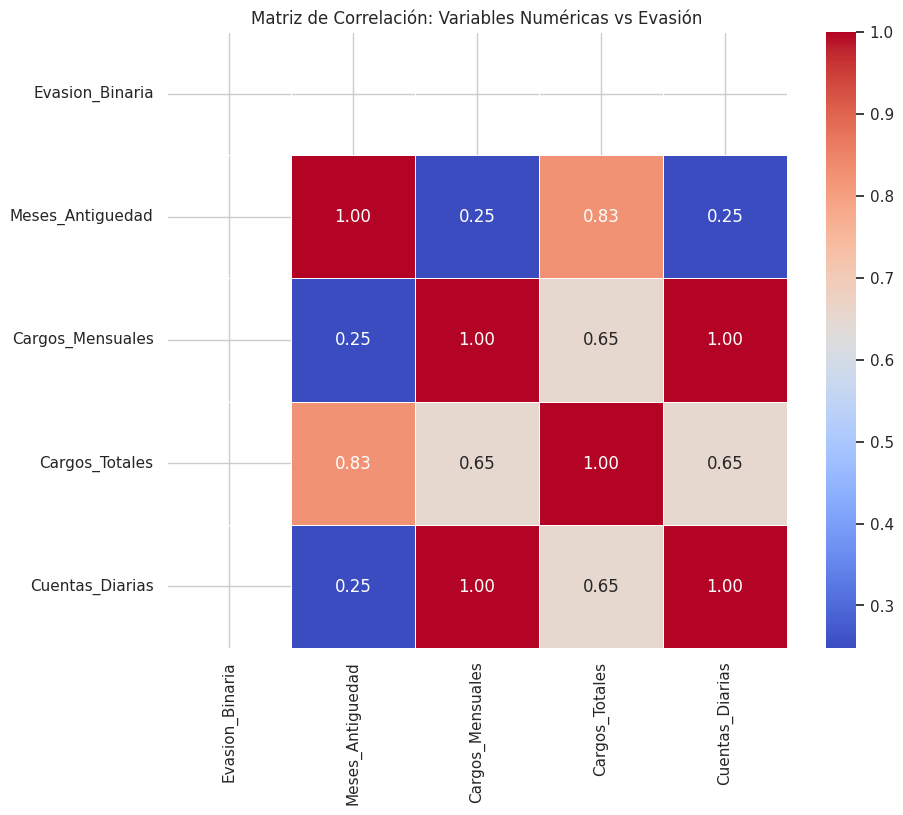

In [ ]:
# Seleccionamos las variables numéricas clave para el mapa de calor
variables_correlacion = df_final[['Evasion_Binaria', 'Meses_Antiguedad', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']]

# Calculamos la matriz de correlación
matriz_corr = variables_correlacion.corr()

# Visualización con un Mapa de Calor (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Variables Numéricas vs Evasión')
plt.show()

##Análisis de Servicios Contratados

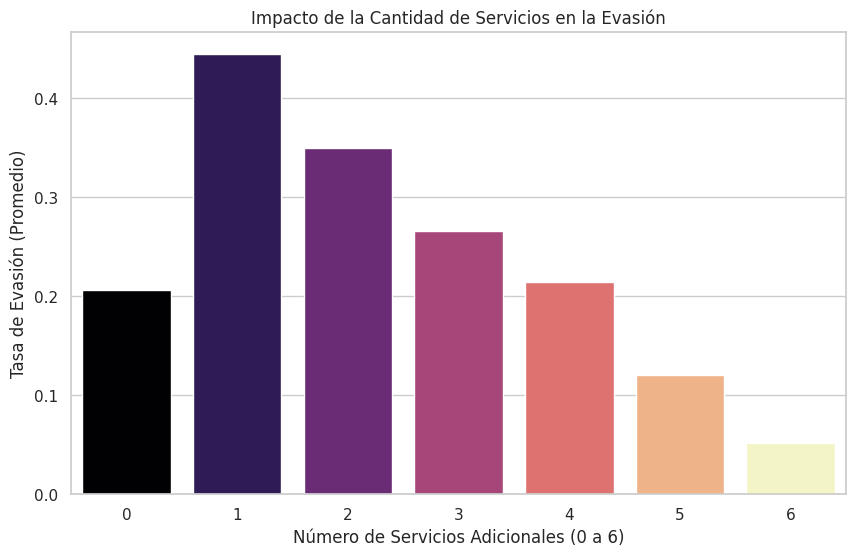

Tasa de evasión por cantidad de servicios:
Total_Servicios
0    0.206342
1    0.444668
2    0.349716
3    0.266319
4    0.214689
5    0.120748
6    0.051546
Name: Evasion_Binaria, dtype: float64


In [ ]:
# 1. Aseguramos que Evasion_Binaria sea numérica (0 y 1)
# 'yes' será 1 y cualquier otra cosa será 0
df_final['Evasion_Binaria'] = df_final['Evasion'].astype(str).str.lower().str.strip().map({'yes': 1, 'no': 0}).fillna(0)

# 2. Lista de servicios
servicios_reales = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# 3. Conteo de servicios
df_final['Total_Servicios'] = df_final[servicios_reales].apply(
    lambda x: x.astype(str).str.lower().str.strip().isin(['yes', 'si']).sum(), axis=1
)

# 4. Gráfico Final
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_final,
    x='Total_Servicios',
    y='Evasion_Binaria',
    hue='Total_Servicios',
    palette='magma',
    legend=False,
    errorbar=None
)

plt.title('Impacto de la Cantidad de Servicios en la Evasión')
plt.xlabel('Número de Servicios Adicionales (0 a 6)')
plt.ylabel('Tasa de Evasión (Promedio)')
plt.show()

# 5. Verificación
print("Tasa de evasión por cantidad de servicios:")
print(df_final.groupby('Total_Servicios')['Evasion_Binaria'].mean())

/tmp/ipykernel_202/1635061524.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasion', y='Cuentas_Diarias', palette='Set2')


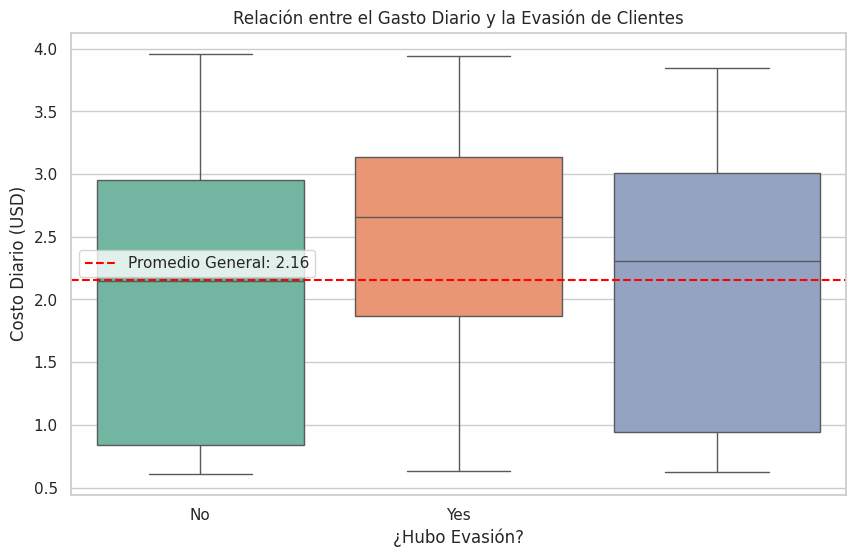

Resumen de Gasto Diario por estado de Evasión:
          count      mean       std   min    25%    50%     75%   max
Evasion                                                              
          224.0  2.113795  1.046431  0.62  0.945  2.305  3.0125  3.85
No       5174.0  2.042080  1.036492  0.61  0.840  2.150  2.9500  3.96
Yes      1869.0  2.481450  0.822287  0.63  1.870  2.660  3.1400  3.94


In [ ]:
# --- ANÁLISIS EXTRA: CUENTA DIARIA VS EVASIÓN ---

plt.figure(figsize=(10, 6))
# Usamos un Boxplot para ver la distribución del costo diario entre los que se van y los que se quedan
sns.boxplot(data=df_final, x='Evasion', y='Cuentas_Diarias', palette='Set2')

plt.title('Relación entre el Gasto Diario y la Evasión de Clientes')
plt.xlabel('¿Hubo Evasión?')
plt.ylabel('Costo Diario (USD)')

# Añadimos una línea con el promedio para que sea más fácil comparar
promedio_diario = df_final['Cuentas_Diarias'].mean()
plt.axhline(promedio_diario, color='red', linestyle='--', label=f'Promedio General: {promedio_diario:.2f}')
plt.legend()

plt.show()

# Resumen numérico para confirmar lo que vemos en el gráfico
print("Resumen de Gasto Diario por estado de Evasión:")
print(df_final.groupby('Evasion')['Cuentas_Diarias'].describe())